# Vehicle data overview

Two stacked bar charts per source file: vehicle counts by powertrain and by vehicle class.
Counts are summed by **reporting year**, including all first-registration cohorts where present.
Fleet stock is reported on **1 January** of the year shown (2017?2026); deregistrations and new registrations cover 2016?2025.
The source category **Hybrid** is kept as provided, without splitting it into hybrid subtypes.

Run all cells to display the six charts. Sources: the three CSV files in the project-root `Data` folder.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Find the project root when launched from analysis or the project directory.
ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "Data" / "321-140-17133-26-ABS.csv").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start the notebook from the project directory or its analysis folder.")
DATA_DIR = ROOT / "Data"

POWERTRAINS = {
    "Benzin": "Petrol",
    "Diesel": "Diesel",
    "Elektro (BEV)": "Battery electric (BEV)",
    "Hybrid": "Hybrid",
    "Flüssiggas (LPG) (einschl. bivalent)": "LPG (incl. bi-fuel)",
    "Erdgas (CNG) (einschl. bivalent)": "CNG (incl. bi-fuel)",
    "Sonstige": "Other",
}
VEHICLE_CLASSES = {
    "Minis": "Mini cars",
    "Kleinwagen": "Small cars",
    "Kompaktklasse": "Compact cars",
    "Mittelklasse": "Mid-size cars",
    "Obere Mittelklasse": "Upper mid-size cars",
    "Oberklasse": "Luxury cars",
    "SUVs": "SUVs",
    "Geländewagen": "Off-road vehicles",
    "Sportwagen": "Sports cars",
    "Mini-Vans": "Mini MPVs",
    "Großraum-Vans": "Large MPVs",
    "Utilities": "Utilities",
    "Wohnmobile": "Motorhomes",
    "Sonstige": "Other",
}
POWERTRAIN_COLORS = dict(zip(POWERTRAINS.values(), [
    "#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756", "#72B7B2", "#9D9D9D"
]))
CLASS_COLORS = dict(zip(VEHICLE_CLASSES.values(), plt.get_cmap("tab20").colors[:14]))
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "figure.dpi": 120})


In [2]:
def load_data(filename):
    df = pd.read_csv(DATA_DIR / filename, sep=";", encoding="cp1252")
    required = ["Berichtsjahr", "Segment", "Antriebsart", "Anzahl"]
    if df[required].isna().any().any():
        raise ValueError(f"Missing values in {filename}")
    # Supports both annual values and stock reference dates (DD.MM.YYYY).
    df["Year"] = df["Berichtsjahr"].astype(str).str.extract(r"(\d{4})$", expand=False).astype(int)
    df["Anzahl"] = pd.to_numeric(df["Anzahl"], errors="raise")
    if (df["Anzahl"] < 0).any():
        raise ValueError(f"Negative vehicle counts in {filename}")
    for column, labels in [("Antriebsart", POWERTRAINS), ("Segment", VEHICLE_CLASSES)]:
        unknown = set(df[column]) - set(labels)
        if unknown:
            raise ValueError(f"Unmapped categories in {filename}: {unknown}")
    return df


def plot_composition(df, column, labels, colors, title, legend_title, stock=False):
    counts = (df.groupby(["Year", column])["Anzahl"].sum()
              .unstack(fill_value=0).sort_index()
              .reindex(columns=list(labels), fill_value=0)
              .rename(columns=labels))
    # Each stack must reproduce the full annual count in the source data.
    pd.testing.assert_series_equal(
        counts.sum(axis=1), df.groupby("Year")["Anzahl"].sum(), check_names=False
    )
    fig, ax = plt.subplots(figsize=(13, 7))
    counts.plot.bar(stacked=True, ax=ax, width=0.78,
                    color=[colors[c] for c in counts.columns], edgecolor="white", linewidth=0.25)
    ax.set_title(title, pad=15)
    ax.set_xlabel("Year (stock on 1 January)" if stock else "Year")
    ax.set_ylabel("Number of vehicles")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(bottom=0)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title=legend_title, loc="upper center", bbox_to_anchor=(0.5, -0.17),
              ncol=4, frameon=False, fontsize=9, title_fontsize=10)
    fig.subplots_adjust(left=0.11, right=0.98, top=0.9, bottom=0.32)
    plt.show()
    plt.close(fig)


## Vehicle deregistrations

Source: `321-140-17133-26-ABS.csv`

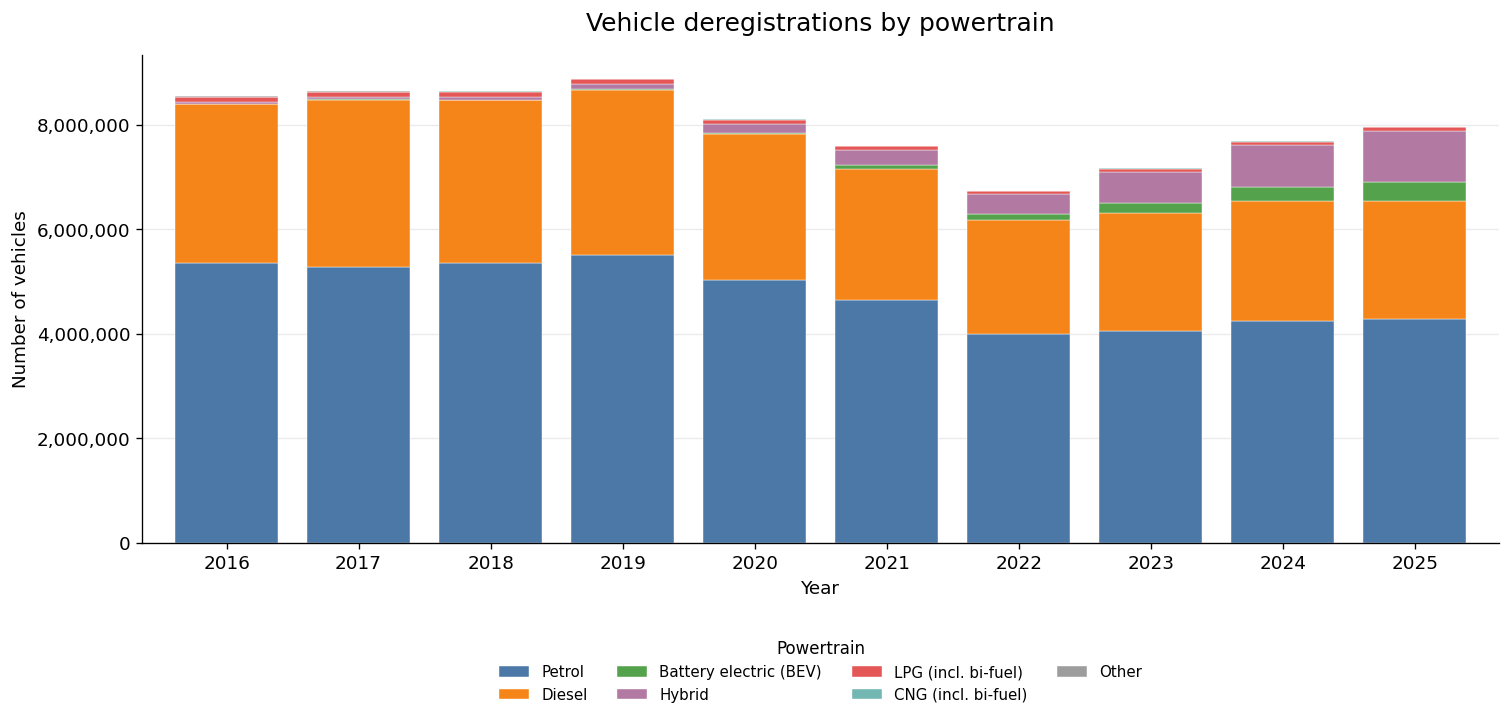

In [3]:
data = load_data("321-140-17133-26-ABS.csv")
plot_composition(data, "Antriebsart", POWERTRAINS, POWERTRAIN_COLORS,
                 "Vehicle deregistrations by powertrain", "Powertrain", stock=False)

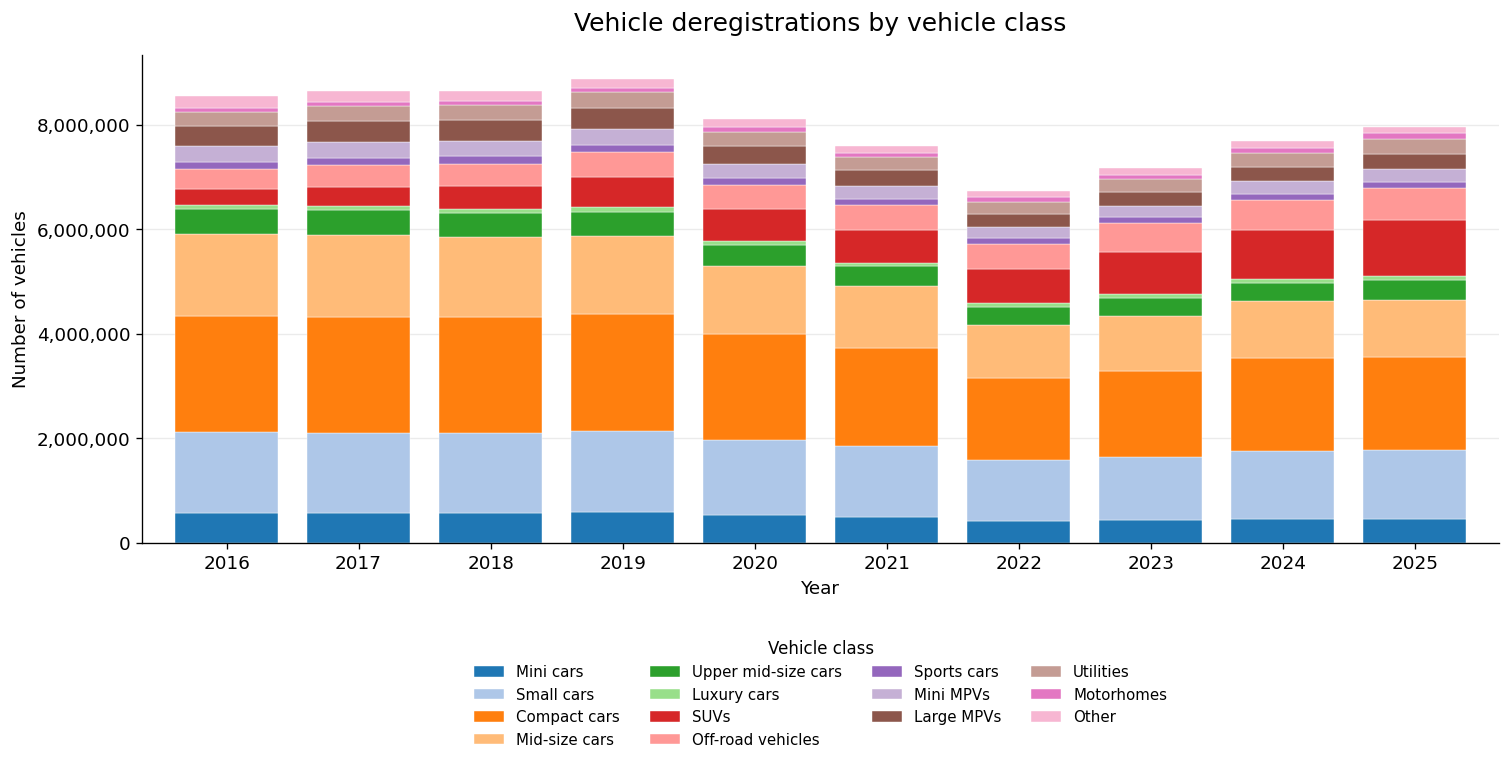

In [4]:
plot_composition(data, "Segment", VEHICLE_CLASSES, CLASS_COLORS,
                 "Vehicle deregistrations by vehicle class", "Vehicle class", stock=False)

## Vehicle stock

Source: `321-140-17133-26-Bestand.csv`

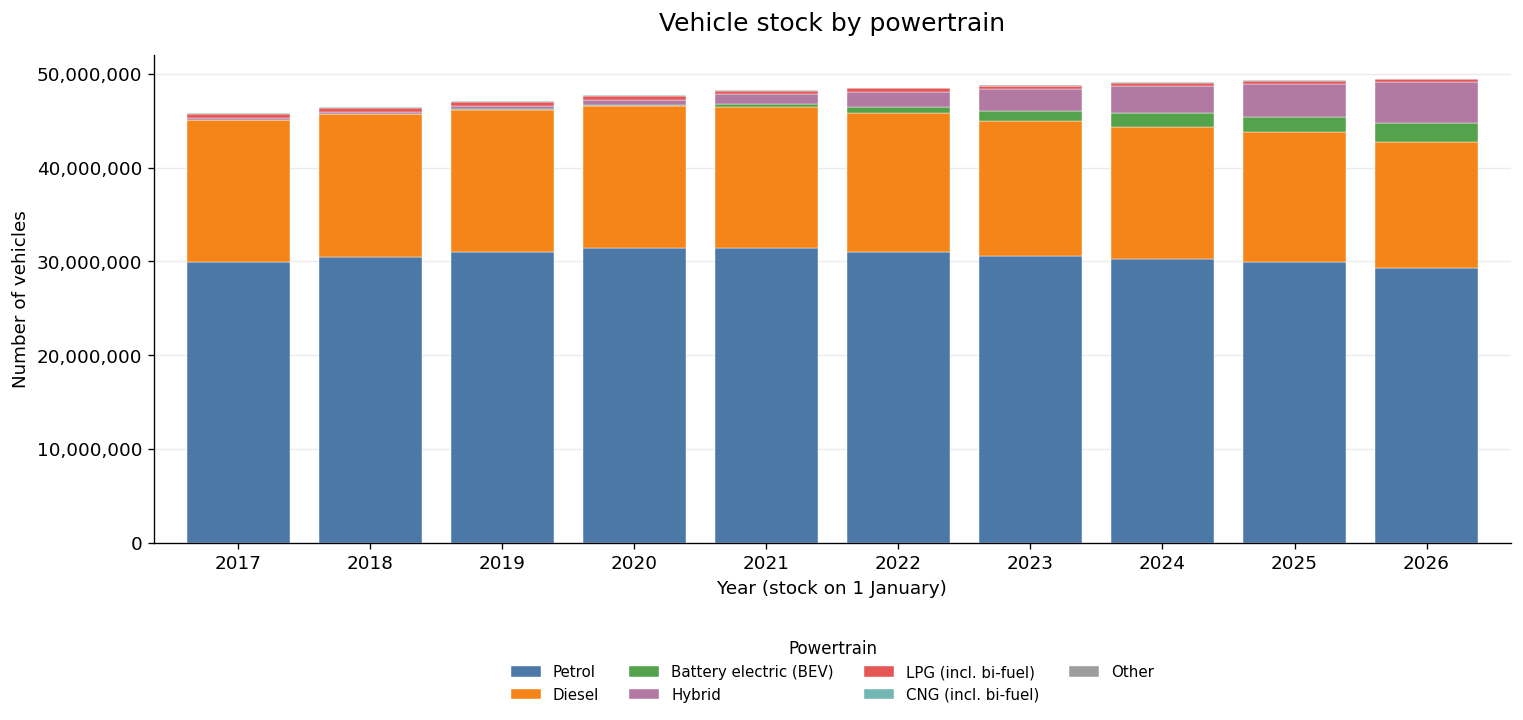

In [5]:
data = load_data("321-140-17133-26-Bestand.csv")
plot_composition(data, "Antriebsart", POWERTRAINS, POWERTRAIN_COLORS,
                 "Vehicle stock by powertrain", "Powertrain", stock=True)

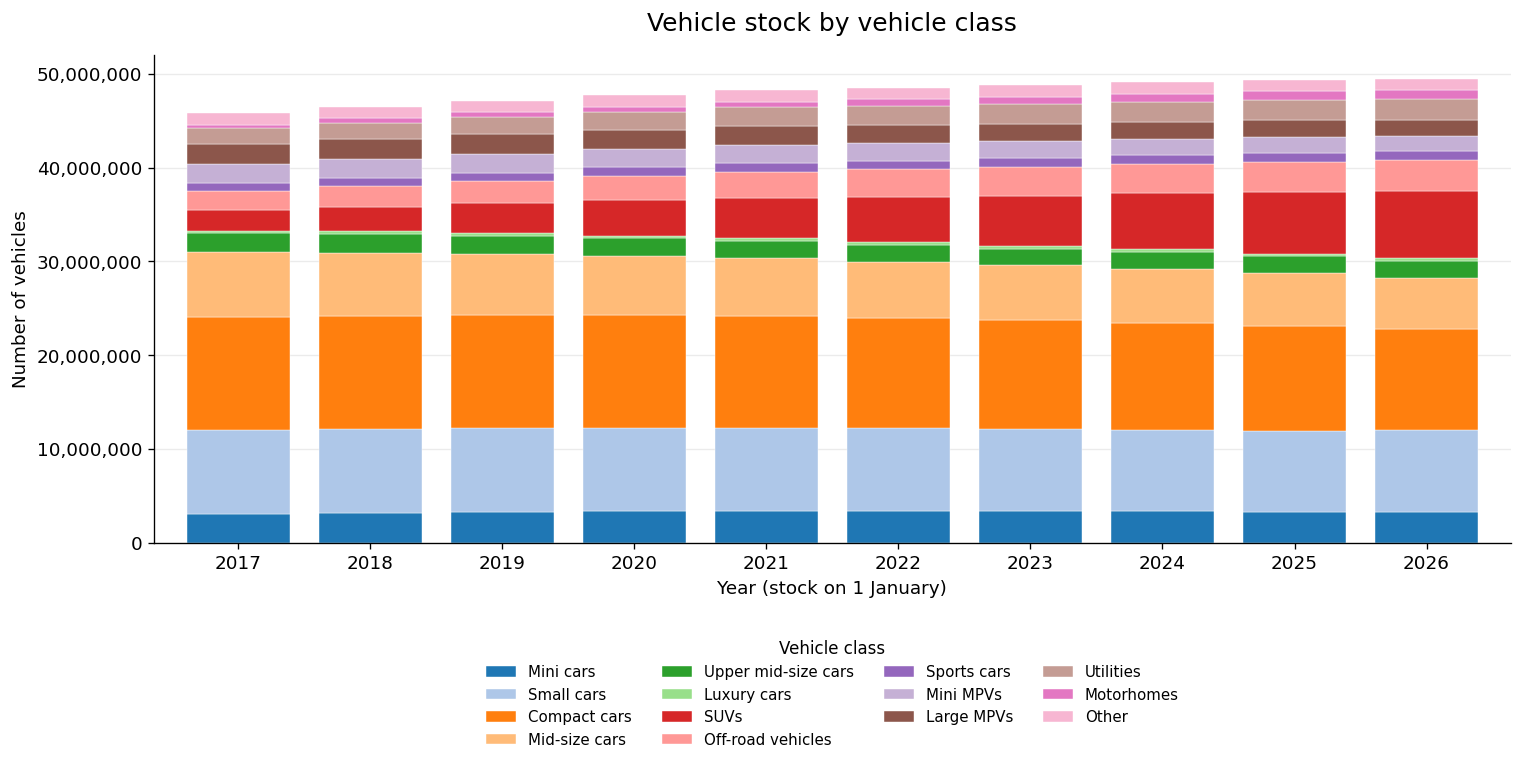

In [6]:
plot_composition(data, "Segment", VEHICLE_CLASSES, CLASS_COLORS,
                 "Vehicle stock by vehicle class", "Vehicle class", stock=True)

## New vehicle registrations

Source: `321-140-17133-26-NZL.csv`

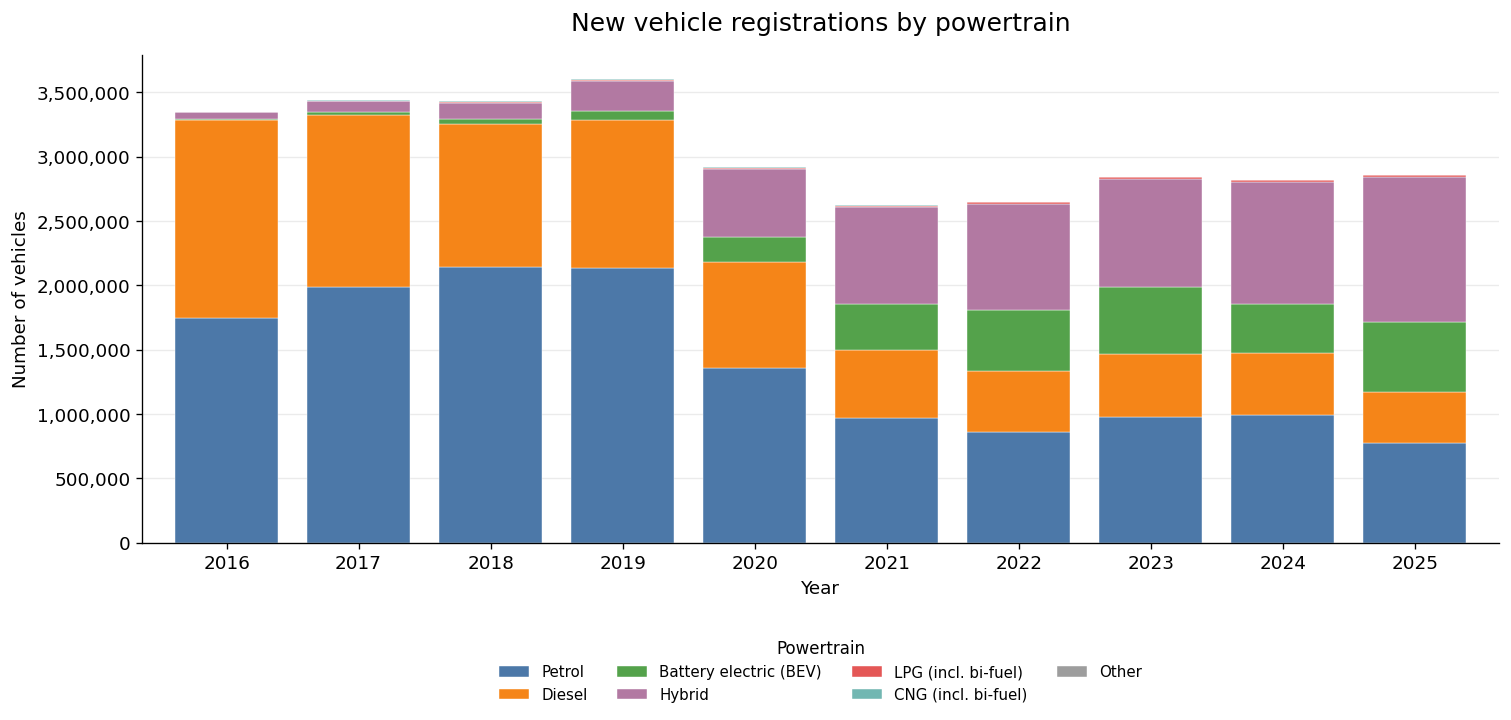

In [7]:
data = load_data("321-140-17133-26-NZL.csv")
plot_composition(data, "Antriebsart", POWERTRAINS, POWERTRAIN_COLORS,
                 "New vehicle registrations by powertrain", "Powertrain", stock=False)

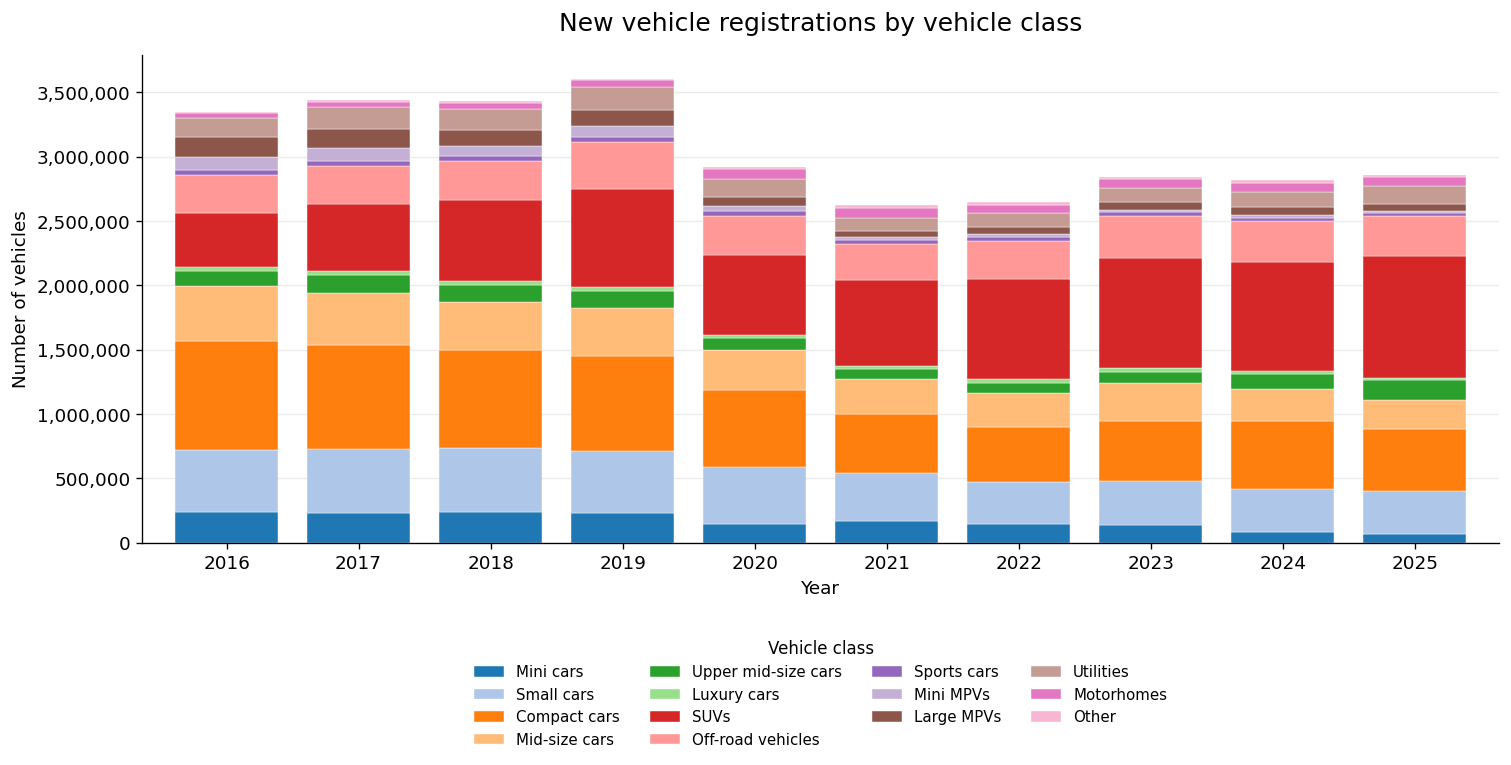

In [8]:
plot_composition(data, "Segment", VEHICLE_CLASSES, CLASS_COLORS,
                 "New vehicle registrations by vehicle class", "Vehicle class", stock=False)